<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/L2_Regularisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [14]:
X,y =make_moons(100, noise = 0.25, random_state=42)

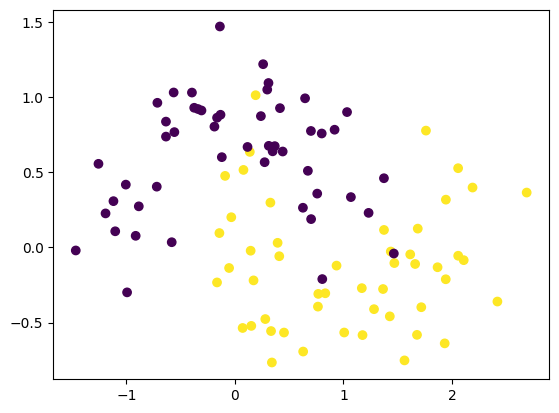

In [15]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [16]:
model = Sequential()

model.add(Dense(64, input_dim=2, activation="relu"))
model.add(Dense(32, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
adam = Adam(learning_rate=0.01)
model.compile(loss="binary_crossentropy", optimizer = adam, metrics=["accuracy"])

In [31]:
model.fit(X,y,epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9461 - loss: 0.1407 - val_accuracy: 0.9500 - val_loss: 0.1776
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9617 - loss: 0.1271 - val_accuracy: 0.9500 - val_loss: 0.1816
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9617 - loss: 0.1157 - val_accuracy: 0.9500 - val_loss: 0.1775
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9617 - loss: 0.1135 - val_accuracy: 0.9500 - val_loss: 0.1711
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9539 - loss: 0.1135 - val_accuracy: 0.9500 - val_loss: 0.1679
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9461 - loss: 0.1198 - val_accuracy: 0.9500 - val_loss: 0.1692
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9578 - loss: 0.1044 - val_accuracy: 0.9500 - val_loss: 0.1719
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9617 - loss: 0.0965 - val_accuracy: 0.9500 - val_loss

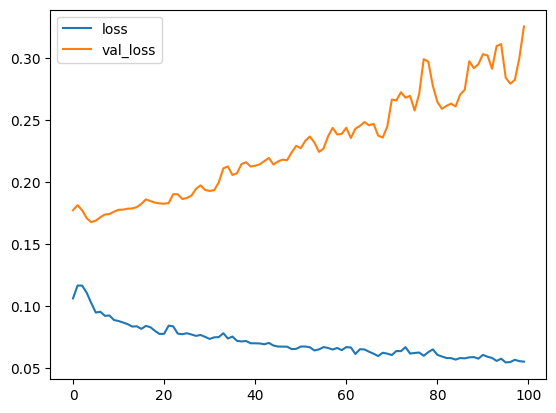

In [32]:
plt.plot(model.history.history["loss"])
plt.plot(model.history.history["val_loss"])
plt.legend(["loss", "val_loss"])
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

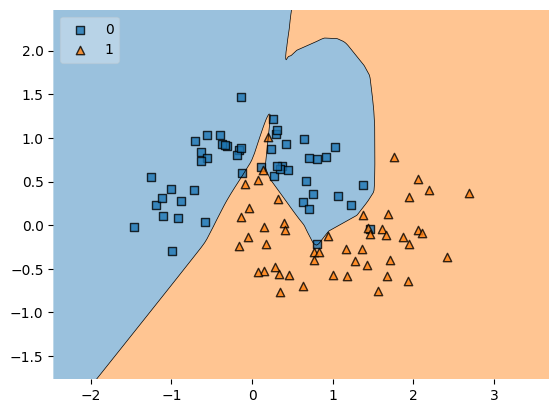

In [33]:
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)
#over=fitting

In [50]:
model2 = Sequential()

model2.add(Dense(128, input_dim=2, activation="relu", kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(128, activation="relu", kernel_regularizer= tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1, activation = "sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
adam =Adam(learning_rate = 0.01)
model2.compile(loss="binary_crossentropy", optimizer=adam, metrics=["accuracy"])

In [53]:
model2.fit(X,y, epochs = 1000, validation_split=0.2)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.6313 - loss: 4.2471 - val_accuracy: 0.8000 - val_loss: 2.7350
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8172 - loss: 2.4604 - val_accuracy: 0.8000 - val_loss: 1.5961
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8586 - loss: 1.4012 - val_accuracy: 0.8000 - val_loss: 0.9919
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8383 - loss: 0.8545 - val_accuracy: 0.8000 - val_loss: 0.7420
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8492 - loss: 0.6598 - val_accuracy: 0.8000 - val_loss: 0.6781
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8766 - loss: 0.5809 - val_accuracy: 0.8000 - val_loss: 0.6796
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8406 - loss: 0.5789 - val_accuracy: 0.8500 - val_loss: 0.6853
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8227 - loss: 0.5982 - val_accuracy: 0.8000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

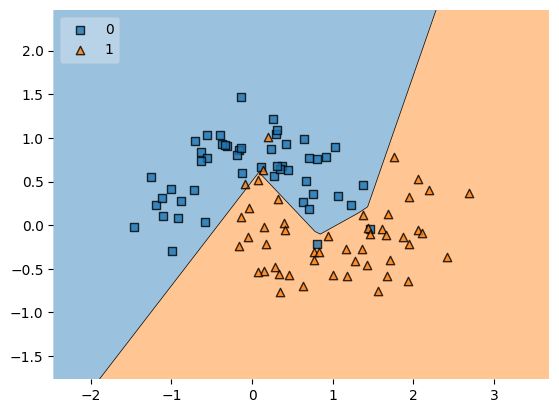

In [54]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
#no-overfitting

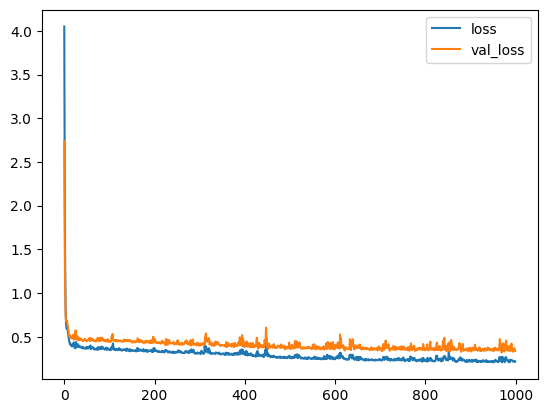

In [55]:
plt.plot(model2.history.history["loss"])
plt.plot(model2.history.history["val_loss"])
plt.legend(["loss", "val_loss"])
plt.show()